# Indoor VPR experiment workbench

Change the dataset and algorithm in **Configuration**, then run all cells. Results stay in memory so you can inspect individual matches without recomputing descriptors.

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr import DatasetConfig, ImageDataset, create_algorithm, list_algorithms, run_vpr
from indoor_vpr.visualization import show_matches, show_similarity_matrix

print('Algorithms:', list_algorithms())

Algorithms: ['dinov2', 'rgb_histogram']


## Configuration

This is the only cell you normally need to edit. Use `rgb_histogram` for a quick baseline or `dinov2` for learned descriptors. Set either limit to `None` to use every image.

In [4]:
# Dataset: change these two folders for a new experiment.
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-1'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3597'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3598'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None

# Algorithm: choose a name printed above and its constructor options.
ALGORITHM = 'rgb_histogram'  # Try: 'rgb_histogram' or 'dinov2'
ALGORITHM_OPTIONS = {
    'rgb_histogram': {'bins': 32},
    'dinov2': {'model_name': 'dinov2_vitb14', 'batch_size': 16},
}
TOP_K = 5

## Load the selected dataset

In [5]:
dataset_config = DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
)
dataset = ImageDataset.from_config(dataset_config)
print(dataset.summary())

Database: 12 images | Queries: 27 images


## Run retrieval

In [6]:
algorithm = create_algorithm(ALGORITHM, **ALGORITHM_OPTIONS.get(ALGORITHM, {}))
print(f'Running {algorithm.name} ...')
results = run_vpr(dataset, algorithm)
print(f'Done: {results.similarity.shape[0]} queries × {results.similarity.shape[1]} database images')

Running rgb_histogram ...
Done: 27 queries × 12 database images


## Inspect the outputs

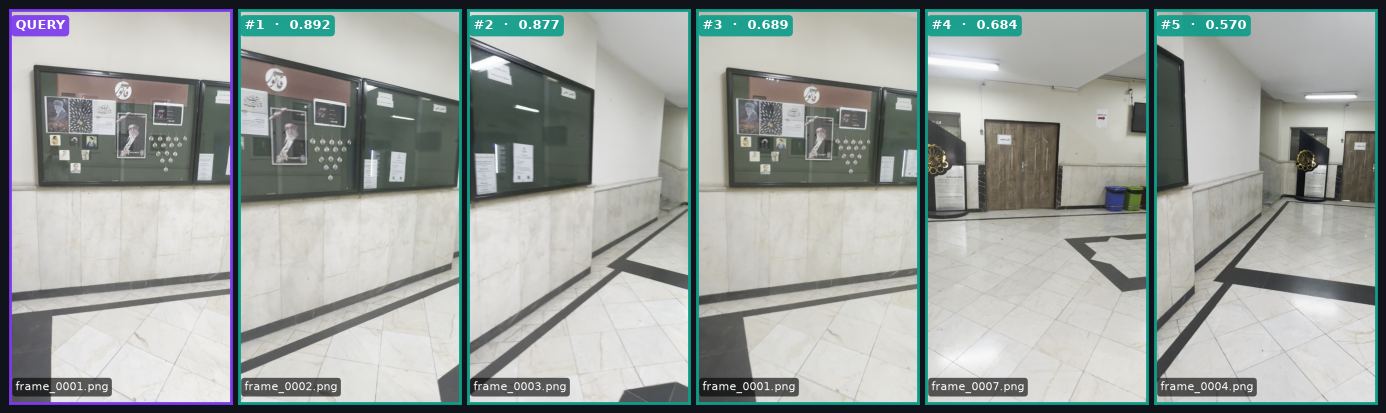

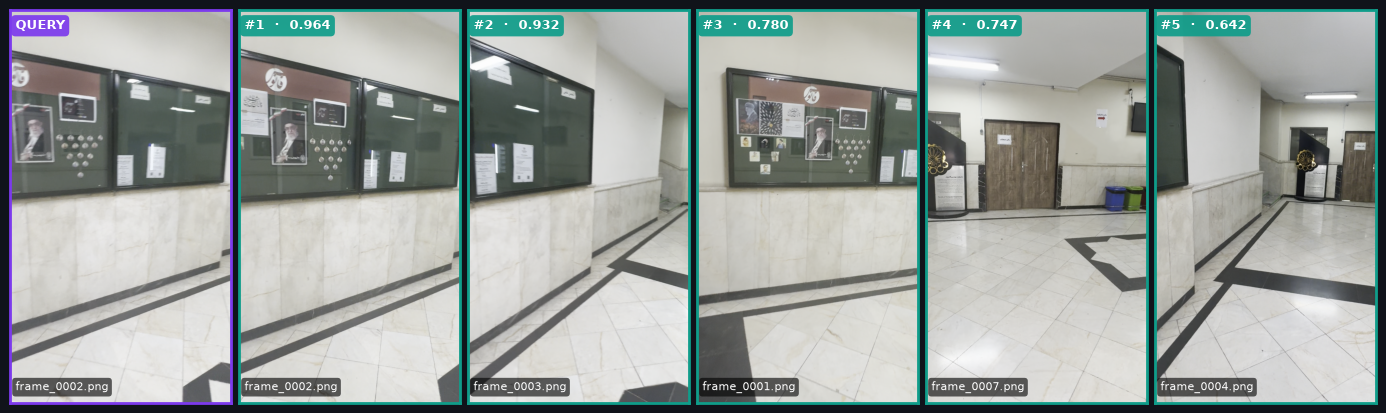

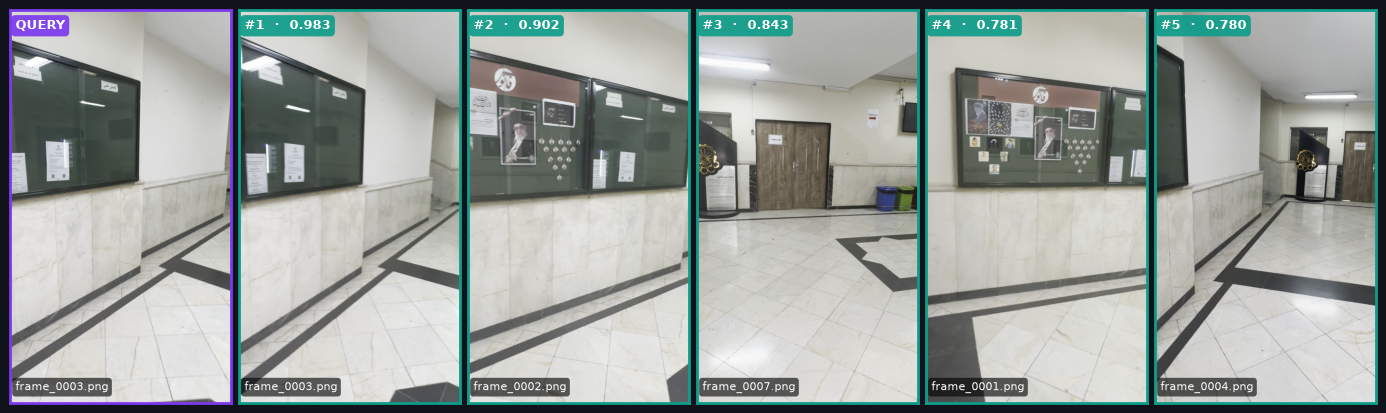

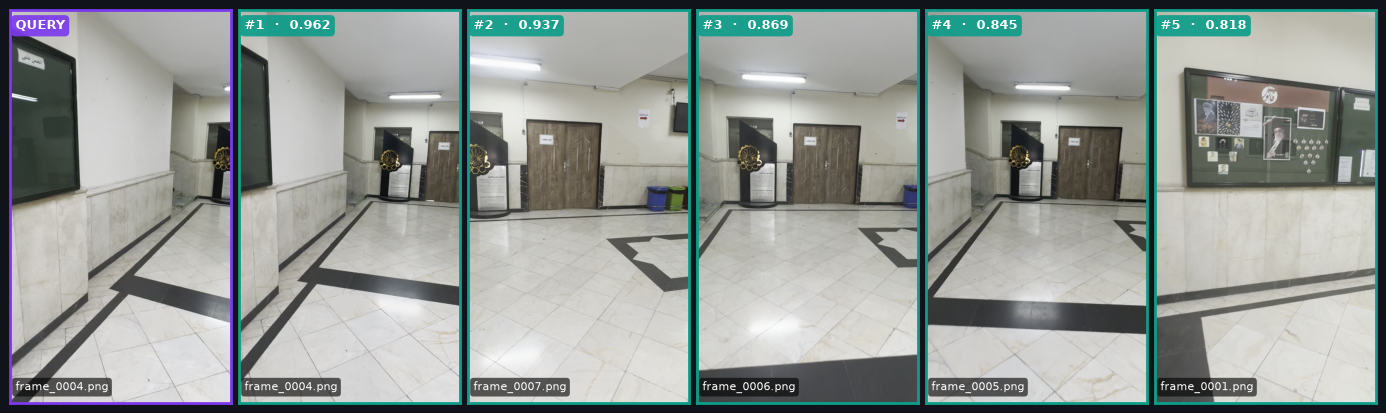

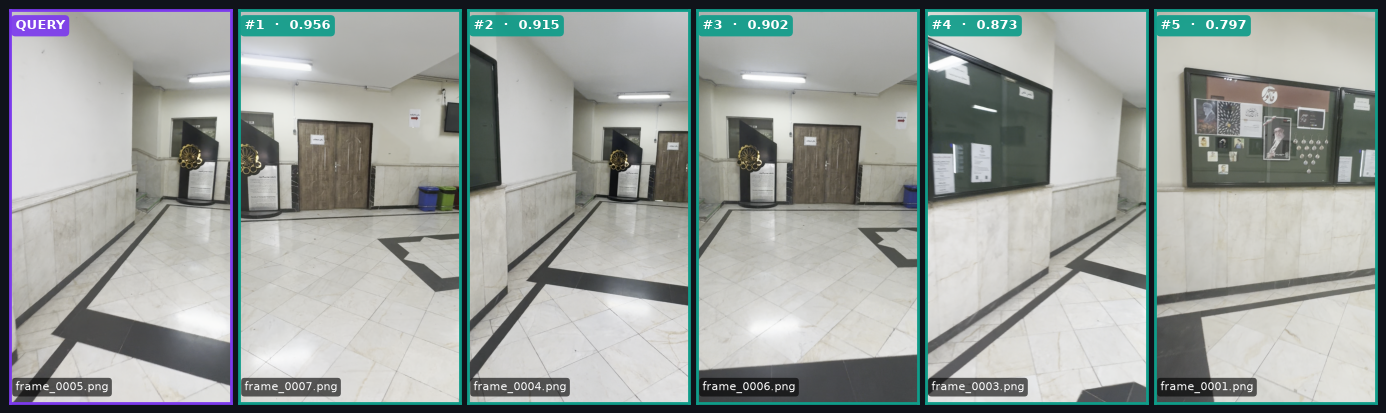

In [7]:
QUERY_INDEX = 5  # Change this to inspect another query.
for i in range(0, 5):
    show_matches(results, query_index=i, top_k=TOP_K);

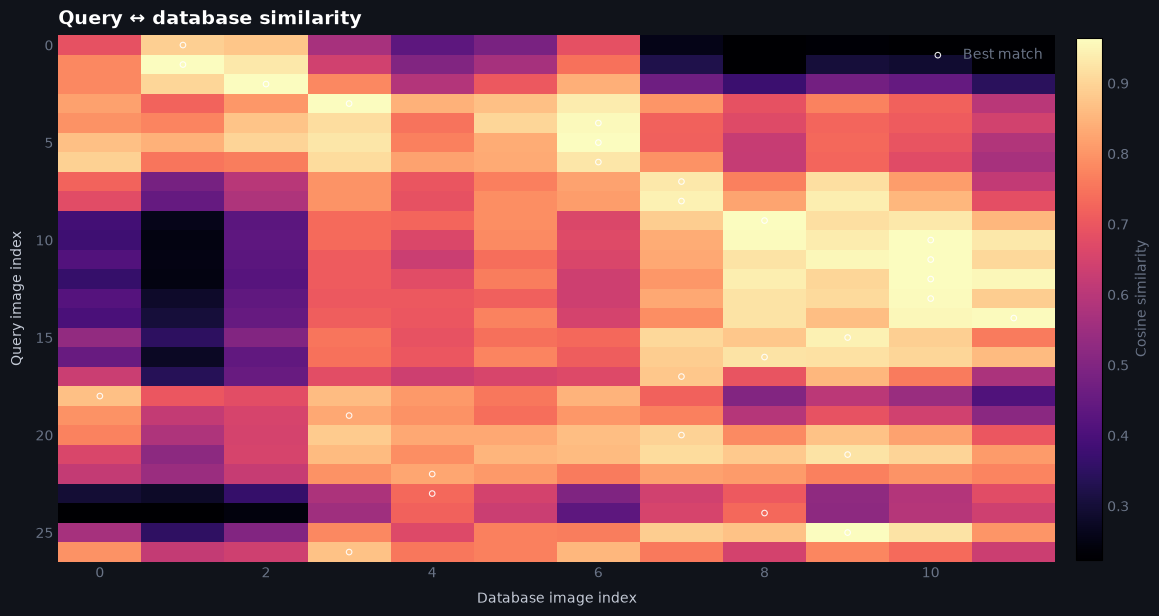

In [8]:
show_similarity_matrix(results);

## Add another VPR algorithm

Create a class derived from `VPRAlgorithm` with an `encode(image_paths)` method returning a NumPy array shaped `(number_of_images, descriptor_size)`. Register it once, then select its name in the configuration cell. Permanent implementations belong in their own module under `src/indoor_vpr/algorithms/`.

In [9]:
# Example skeleton (uncomment and implement):
# from indoor_vpr.core import VPRAlgorithm, register_algorithm
# class MyVPR(VPRAlgorithm):
#     name = 'my_vpr'
#     def encode(self, image_paths):
#         ...  # Return a float NumPy array with one descriptor per path.
# register_algorithm(MyVPR.name, MyVPR)